In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Uso de dispositivo: {device}")
import numpy as np
import pandas as pd
import seaborn as sn  # for heatmaps
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

Uso de dispositivo: cuda


In [2]:
# primer paso leeer los datos
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Definimos las rutas exactas a las dos carpetas principales
ruta_base = "/home/fred/asl"
ruta_train = os.path.join(ruta_base, "asl_alphabet_train")
ruta_test = os.path.join(ruta_base, "asl_alphabet_test")

# definimos las transformaciones
transform_train= transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# para el tests nunca se rotan ni se alteran, solo se redimensionan
transform_test= transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [3]:
from PIL import Image
from torch.utils.data import Dataset

class ASLTestDataset(Dataset):
    def __init__(self, test_dir, class_names, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.class_names = class_names  # lista de clases del train
        
        # Guardar todas las imágenes con su etiqueta
        self.samples = []
        
        for filename in os.listdir(test_dir):
            if filename.endswith('.png') or filename.endswith('.jpg'):
                # Extraer la letra del nombre: "a_test.1.png" → "a"
                label_str = filename.split('_')[0].upper()
                
                if label_str in class_names:
                    label_idx = class_names.index(label_str)
                    filepath = os.path.join(test_dir, filename)
                    self.samples.append((filepath, label_idx))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        image = Image.open(filepath).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [4]:
# crear los datasets independinetes usando image Folder
train_dataset= datasets.ImageFolder(root=ruta_train,transform=transform_train)
class_names=train_dataset.classes#['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z','del','nothing','space']

test_dataset=ASLTestDataset(test_dir=ruta_test,class_names=class_names,transform=transform_test)

# data loader 
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True,num_workers=0)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=True,num_workers=0)

In [5]:
# Verificar
print(f"Train: {len(train_dataset)} imágenes")
print(f"Test:  {len(test_dataset)} imágenes")
print(f"Clases: {class_names}")

Train: 87000 imágenes
Test:  29 imágenes
Clases: ['A', 'B', 'C', 'D', 'DEL', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'NOTHING', 'O', 'P', 'Q', 'R', 'S', 'SPACE', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Label: [   23    10    10     8    16     7    17    18    16     7    26    19
    28    24    18     0     8    16    12    26    27    13    15     1
    25    18    11     8    27    16    14    19]
Class:  U J J H O G P Q O G X R Z V Q A H O L X Y M NOTHING B W Q K H Y O N R


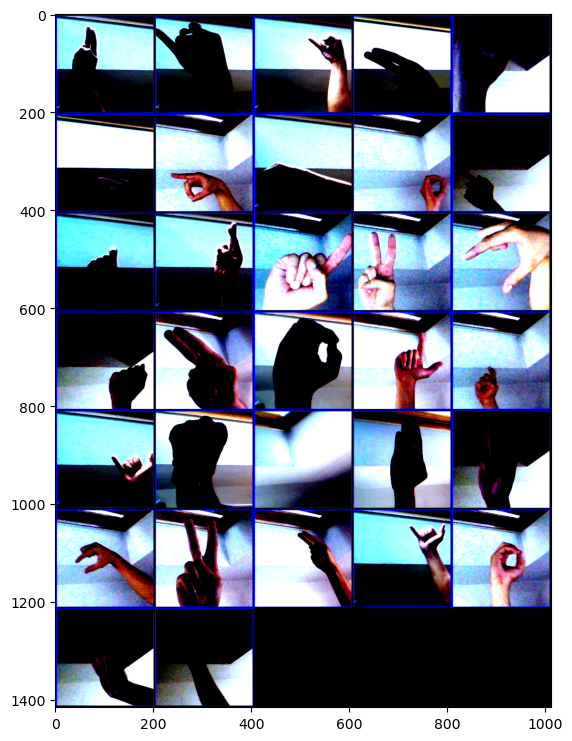

In [6]:
np.set_printoptions(formatter=dict(int=lambda x: f'{x:5}')) # to widen the printed array

# Grab the first batch of 10 images
for images,labels in train_loader: 
    break

# Print the labels
print('Label:', labels.numpy())
print('Class: ', *np.array([class_names[i] for i in labels]))

# Print the images
im = make_grid(images, nrow=5)  # the default nrow is 8
plt.figure(figsize=(15,9))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

In [7]:
# luego definir el modelo
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
import torchvision.models as models

# 1. Descargamos una ResNet-18 preentrenada
# (Ya está diseñada perfectamente para imágenes grandes)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Vemos cuántas entradas tenía su última capa lineal original
num_ftrs = model.fc.in_features  # En ResNet-18 suele ser 512

# 3. Reemplazamos SU última capa por una que se adapte a TU problema
# Suponiendo que tu dataset tiene, por ejemplo, 10 o 24 clases
mis_clases_de_salida = 29
model.fc = nn.Linear(num_ftrs, mis_clases_de_salida)

# ¡Listo! Ya tienes una arquitectura de nivel profesional adaptada a tus imágenes

In [8]:
# parametro de perdida 
criterion= nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- ASEGURATE DE QUE EL MODELO ESTÉ EN EL DEVICE ---
model = model.to(device) 

start_time = time.time()

epochs = 4
train_losses = []
test_losses = []
train_correct = []
test_correct = []

total_train_imgs = len(train_loader.dataset)
total_test_imgs = len(test_loader.dataset)#val_loader

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    running_train_loss = 0.0
    running_test_loss = 0.0
    
    # Listas para almacenar las predicciones de la ÚLTIMA época
    todas_las_etiquetas = []
    todas_las_predicciones = []
    
    # --- FASE DE ENTRENAMIENTO ---
    model.train() 
    
    for b, (X_train, y_train) in enumerate(train_loader):
        b += 1

        # Mover datos al dispositivo (CPU o GPU)
        X_train = X_train.to(device)
        y_train = y_train.to(device)
        
        # Apply the model
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
 
        # Tally the number of correct predictions
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr
        running_train_loss += loss.item() 
        
        # Update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Print interim results
        if b % 50 == 0:
            imagenes_procesadas = b * train_loader.batch_size
            accuracy_actual = trn_corr.item() * 100 / imagenes_procesadas
            print(f'epoch: {i+1:2}  batch: {b:4} [{imagenes_procesadas:6}/{total_train_imgs}]  '
                  f'loss: {loss.item():10.8f}  accuracy: {accuracy_actual:7.3f}%')
        
    train_losses.append(running_train_loss / len(train_loader))
    train_correct.append(trn_corr)
        
    # --- FASE DE TEST / EVALUACIÓN ---
    model.eval() 
    
    with torch.no_grad(): 
        for b_test, (X_test, y_test) in enumerate(test_loader):
            # Mover datos al dispositivo
            X_test = X_test.to(device)
            # Nota: Si usas la clase personalizada de test con strings, y_test no irá al device,
            # pero asumimos que aquí ya tienes las etiquetas mapeadas numéricamente.
            y_test_dev = y_test.to(device) 
            
            # Apply the model
            y_val = model(X_test)
            
            # Calculamos el loss de CADA batch
            loss_v = criterion(y_val, y_test_dev)
            running_test_loss += loss_v.item()

            # Tally the number of correct predictions
            predicted = torch.max(y_val.data, 1)[1] 
            tst_corr += (predicted == y_test_dev).sum()
            
            # Solo guardamos los datos para la matriz en la ÚLTIMA época
            if i == epochs - 1:
                todas_las_etiquetas.extend(y_test.cpu().numpy())
                todas_las_predicciones.extend(predicted.cpu().numpy())
            
    # Guardamos los resultados finales de test de esta época
    test_losses.append(running_test_loss / len(test_loader))
    test_correct.append(tst_corr)
    
    # Imprimir resumen de fin de época
    print(f'--- FIN ÉPOCA {i+1} ---')
    print(f'Train Accuracy: {trn_corr.item()*100/total_train_imgs:.2f}% | Test Accuracy: {tst_corr.item()*100/total_test_imgs:.2f}%\n')
        
print(f'\nDuration: {time.time() - start_time:.0f} seconds')


# =====================================================================
# --- CÁLCULO Y GRAFICADO DE LA MATRIZ DE CONFUSIÓN ---
# =====================================================================

# 1. Generar la matriz matemática usando scikit-learn
cm = confusion_matrix(todas_las_etiquetas, todas_las_predicciones)

# 2. Conseguir los nombres de las clases (en orden) desde tu train_dataset
# Si no lo tienes a mano, puedes usar list(range(29))
nombres_clases = train_dataset.classes if 'train_dataset' in locals() else [str(n) for n in range(29)]

# 3. Graficarla usando Seaborn para que sea legible (ya que son 29 clases)
plt.figure(figsize=(18, 14)) # Un tamaño grande para que quepan las 29 clases sin amontonarse
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.xlabel('Predicciones del Modelo')
plt.ylabel('Etiquetas Reales (Gold Standard)')
plt.title('Matriz de Confusión')
plt.show()

# 4. Imprimir un reporte detallado en texto (Precision, Recall, F1-Score por clase)
print("\n--- Reporte de Clasificación Detallado ---")
print(classification_report(todas_las_etiquetas, todas_las_predicciones, target_names=nombres_clases))

epoch:  1  batch:   50 [  1600/87000]  loss: 0.08918025  accuracy:  98.438%
epoch:  1  batch:  100 [  3200/87000]  loss: 0.00677237  accuracy:  98.406%
epoch:  1  batch:  150 [  4800/87000]  loss: 0.05954311  accuracy:  98.271%
epoch:  1  batch:  200 [  6400/87000]  loss: 0.07827054  accuracy:  98.203%
epoch:  1  batch:  250 [  8000/87000]  loss: 0.06871480  accuracy:  98.175%
epoch:  1  batch:  300 [  9600/87000]  loss: 0.02438312  accuracy:  98.375%
epoch:  1  batch:  350 [ 11200/87000]  loss: 0.00264517  accuracy:  98.545%
epoch:  1  batch:  400 [ 12800/87000]  loss: 0.04337335  accuracy:  98.602%
epoch:  1  batch:  450 [ 14400/87000]  loss: 0.10346420  accuracy:  98.667%
epoch:  1  batch:  500 [ 16000/87000]  loss: 0.10804519  accuracy:  98.556%
epoch:  1  batch:  550 [ 17600/87000]  loss: 0.11786976  accuracy:  98.460%
epoch:  1  batch:  600 [ 19200/87000]  loss: 0.19985160  accuracy:  98.469%
epoch:  1  batch:  650 [ 20800/87000]  loss: 0.01596542  accuracy:  98.351%
epoch:  1  b

KeyboardInterrupt: 